In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [ ]:
file_path = "/content/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [ ]:
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
print("DATA TYPES")
print(df.dtypes)

print("\nMISSING VALUES")
print(df.isnull().sum())

DATA TYPES
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

MISSING VALUES
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling   

In [ ]:
if 'SupportCalls' in df.columns:
    print("SupportCalls column is present.")
else:
    print("SupportCalls column is NOT present in this dataset.")
    print("The original Telco Customer Churn dataset contains TechSupport,")
    print("but it does not contain the number of support calls.")

SupportCalls column is NOT present in this dataset.
The original Telco Customer Churn dataset contains TechSupport,
but it does not contain the number of support calls.


In [ ]:
data = df[
    [
        'MonthlyCharges',
        'tenure',
        'Contract',
        'Churn'
    ]
].copy()

print("Selected columns:")
display(data.head())

Selected columns:


,MonthlyCharges,tenure,Contract,Churn
0,29.85,1,Month-to-month,No
1,56.95,34,One year,No
2,53.85,2,Month-to-month,Yes
3,42.30,45,One year,No
4,70.70,2,Month-to-month,Yes


In [ ]:
data['MonthlyCharges'] = pd.to_numeric(
    data['MonthlyCharges'],
    errors='coerce'
)

data['tenure'] = pd.to_numeric(
    data['tenure'],
    errors='coerce'
)

print(data.dtypes)

MonthlyCharges    float64
tenure              int64
Contract           object
Churn              object
dtype: object


In [ ]:
print("Missing values before cleaning:")
print(data.isnull().sum())

data.dropna(inplace=True)

print("\nMissing values after cleaning:")
print(data.isnull().sum())

Missing values before cleaning:
MonthlyCharges    0
tenure            0
Contract          0
Churn             0
dtype: int64

Missing values after cleaning:
MonthlyCharges    0
tenure            0
Contract          0
Churn             0
dtype: int64


In [ ]:
data = pd.get_dummies(
    data,
    columns=['Contract'],
    drop_first=False,
    dtype=int
)

print("After encoding Contract:")
display(data.head())

After encoding Contract:


,MonthlyCharges,tenure,Churn,Contract_Month-to-month,Contract_One year,Contract_Two year
0,29.85,1,No,1,0,0
1,56.95,34,No,0,1,0
2,53.85,2,Yes,1,0,0
3,42.30,45,No,0,1,0
4,70.70,2,Yes,1,0,0


In [ ]:
data['Churn'] = data['Churn'].map({
    'No': 0,
    'Yes': 1
})

print(data['Churn'].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [ ]:
X = data.drop('Churn', axis=1)

y = data['Churn']

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print(y.name)

Features (X):
['MonthlyCharges', 'tenure', 'Contract_Month-to-month', 'Contract_One year', 'Contract_Two year']

Target (y):
Churn


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 5634
Testing samples: 1409


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='gini',
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created.")

Random Forest model created.


In [ ]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [ ]:
y_pred = rf_model.predict(X_test)

print("First 20 predictions:")
print(y_pred[:20])

First 20 predictions:
[0 1 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0]


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:")
print(f"{accuracy:.4f}")

print(f"Accuracy Percentage: {accuracy * 100:.2f}%")

Random Forest Accuracy:
0.7580
Accuracy Percentage: 75.80%


In [ ]:
print("Classification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['No Churn', 'Churn']
    )
)

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.81      0.87      0.84      1035
       Churn       0.55      0.45      0.50       374

    accuracy                           0.76      1409
   macro avg       0.68      0.66      0.67      1409
weighted avg       0.75      0.76      0.75      1409



In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[899 136]
 [205 169]]


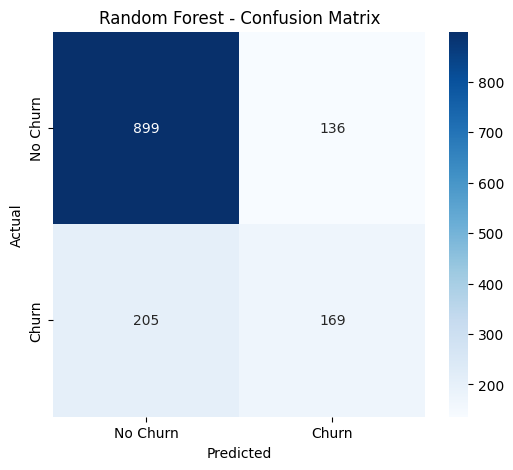

In [ ]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest - Confusion Matrix')

plt.show()

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
0,MonthlyCharges,0.610159
1,tenure,0.253295
2,Contract_Month-to-month,0.098348
4,Contract_Two year,0.028135
3,Contract_One year,0.010062


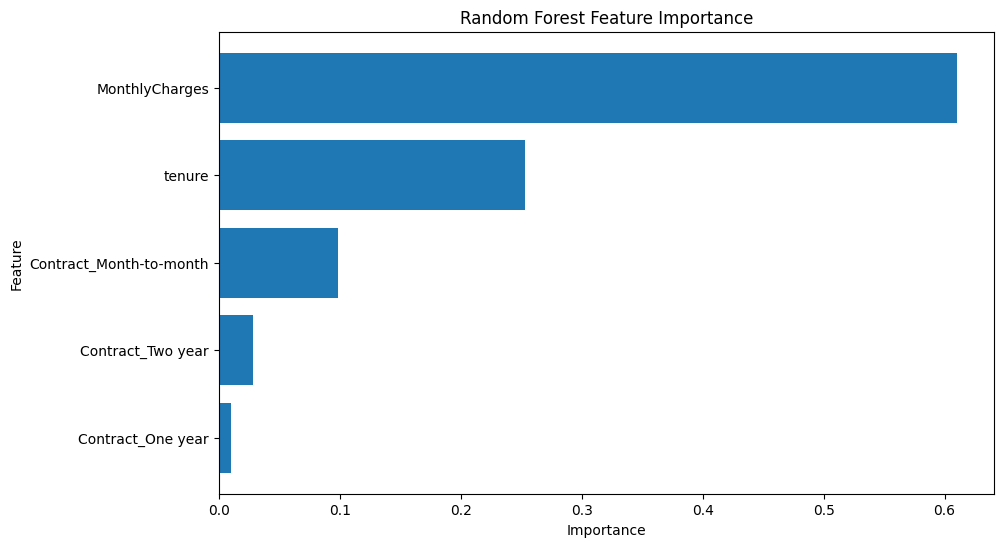

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Random Forest Feature Importance')

plt.gca().invert_yaxis()

plt.show()

In [ ]:
new_customer = pd.DataFrame({
    'MonthlyCharges': [70],
    'tenure': [8],
    'Contract': ['Month-to-month']
})

print("New Customer:")
display(new_customer)

New Customer:


,MonthlyCharges,tenure,Contract
0,70,8,Month-to-month


In [ ]:
new_customer = pd.get_dummies(
    new_customer,
    columns=['Contract'],
    dtype=int
)

print("Encoded New Customer:")
display(new_customer)

Encoded New Customer:


,MonthlyCharges,tenure,Contract_Month-to-month
0,70,8,1


In [ ]:
new_customer = new_customer.reindex(
    columns=X.columns,
    fill_value=0
)

print("Final input format:")
display(new_customer)

Final input format:


,MonthlyCharges,tenure,Contract_Month-to-month,Contract_One year,Contract_Two year
0,70,8,1,0,0


In [ ]:
prediction = rf_model.predict(new_customer)

if prediction[0] == 1:
    print("Predicted Churn: YES")
else:
    print("Predicted Churn: NO")

Predicted Churn: NO


In [ ]:
probability = rf_model.predict_proba(new_customer)

print(f"No Churn Probability: {probability[0][0] * 100:.2f}%")
print(f"Churn Probability: {probability[0][1] * 100:.2f}%")

No Churn Probability: 71.00%
Churn Probability: 29.00%
